## FDSN

In [1]:
import numpy as np
import pandas as pd
from obspy.clients.fdsn import Client
from obspy import UTCDateTime, Stream

client = Client("INGV")

### Stations

In [2]:
# identify the station metadata for ME01/ME02, get the exact vertical channel
inventory = client.get_stations(station="ME01" # or "ME02"
                                ,level="response",
                                starttime = "2008-04-12 00:00:00.000",endtime = "2008-05-13 00:00:00.000")
print(inventory)

Inventory created at 2026-03-14T23:39:15.429000Z
	Created by: INGV-ONT WEB SERVICE: fdsnws-station | version: 1.1.63
		    /exist/apps/fdsn-station/fdsnws/station/1/query?starttime=2008-04-...
	Sending institution: eXistDB (INGV-ONT)
	Contains:
		Networks (1):
			IV
		Stations (1):
			IV.ME01 (Mistretta)
		Channels (3):
			IV.ME01..EHZ, IV.ME01..EHN, IV.ME01..EHE


In [3]:
network = inventory[0]
station = network[0] 
num_channels = len(station)
print ('number of channels: ', num_channels)
print(station)

number of channels:  3
Station ME01 (Mistretta)
	Station Code: ME01
	Channel Count: 3/3 (Selected/Total)
	2007-10-18T00:00:00.000000Z - 2009-02-03T23:00:00.000000Z
	Access: open 
	Latitude: 37.9329, Longitude: 14.3611, Elevation: 944.0 m
	Available Channels:
	    ..EH[ZNE]   125.0 Hz  2007-10-18 to 2009-02-03



In [4]:
channel = [c for c in station if c.code == "EHZ"][0]
print(channel)

Channel 'EHZ', Location '' 
	Time range: 2007-10-18T00:00:00.000000Z - 2009-02-03T23:00:00.000000Z
	Latitude: 37.9329, Longitude: 14.3611, Elevation: 944.0 m, Local Depth: 0.0 m
	Azimuth: 0.00 degrees from north, clockwise
	Dip: -90.00 degrees down from horizontal
	Sampling Rate: 125.00 Hz
	Sensor (Description): None (LENNARTZ LE3D-5S)
	Response information available


### Fetch

In [5]:
# configure the processing parameters for the study
CFG = {
    "network": "IV",
    "location": "",
    "channel": "EHZ",
    "stations": ["ME01", "ME02"],

    # full intended study window
    "start": UTCDateTime("2008-04-12T00:00:00"),
    "end": UTCDateTime("2008-05-14T00:00:00"),

    # process in daily chunks, but pad each day for filtering stability
    "chunk_sec": 24 * 3600,
    "pad_sec": 3600,

    # final base time step of waveform features
    "base_freq": "10min",

    # physical bands
    "bands": {
        "T": (0.05, 0.5),   # teleseismic trigger
        "S": (0.5, 4.0),    # slow background/state
        "Y": (4.0, 12.0),   # HF response/effect
    },

    # metric windows in seconds
    "windows_sec": {
        "T": 30,    # keep trigger sharp
        "S": 600,   # slower state
        "Y": 60,    # response 
    },

    # remove response to velocity
    "response_output": "VEL",
    "pre_filt": (0.02, 0.03, 30.0, 40.0),

    # gap policy
    "max_interp_gap_sec": 2.0,   # only interpolate tiny gaps
}

In [6]:
def fetch_waveform_chunk(station: str, t1: UTCDateTime, t2: UTCDateTime):
    st = client.get_waveforms(
        network=CFG["network"],
        station=station,
        location=CFG["location"],
        channel=CFG["channel"],
        starttime=t1,
        endtime=t2,
        attach_response=True,
    )
    return st

In [7]:
def preprocess_stream_safely(st: Stream):
    st = st.copy()
    st.sort()

    if len(st) == 0:
        raise ValueError("Empty stream")

    st.merge(method=0, fill_value=None)

    if len(st) != 1:
        raise ValueError(f"Expected 1 merged trace, got {len(st)}")

    tr = st[0]

    # convert to float first so NaNs are allowed
    x = np.asarray(tr.data, dtype=float)

    # mask invalid values if any
    data = np.ma.masked_invalid(x)

    sr = tr.stats.sampling_rate
    max_gap_samples = int(CFG["max_interp_gap_sec"] * sr)

    x = data.filled(np.nan)
    isnan = np.isnan(x)

    if isnan.any():
        idx = np.arange(len(x))
        nan_groups = []
        in_gap = False
        start = None

        for i, flag in enumerate(isnan):
            if flag and not in_gap:
                start = i
                in_gap = True
            elif not flag and in_gap:
                nan_groups.append((start, i - 1))
                in_gap = False
        if in_gap:
            nan_groups.append((start, len(x) - 1))

        valid = ~np.isnan(x)

        for g0, g1 in nan_groups:
            gap_len = g1 - g0 + 1
            if gap_len <= max_gap_samples and valid.any():
                left_ok = g0 > 0 and not np.isnan(x[g0 - 1])
                right_ok = g1 < len(x) - 1 and not np.isnan(x[g1 + 1])
                if left_ok and right_ok:
                    x[g0:g1 + 1] = np.interp(
                        idx[g0:g1 + 1],
                        idx[valid],
                        x[valid]
                    )

    tr.data = x.astype(np.float64)

    tr.detrend("linear")
    tr.detrend("demean")
    tr.taper(max_percentage=0.02)

    tr.remove_response(
        output=CFG["response_output"],
        pre_filt=CFG["pre_filt"]
    )

    return tr

In [8]:
def windowed_metric(trace, fmin, fmax, window_sec, out_freq="1min", metric="rms", agg="mean"):
    tr = trace.copy()
    tr.filter("bandpass", freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)

    sr = tr.stats.sampling_rate
    nwin = int(window_sec * sr)
    if nwin <= 0:
        raise ValueError("window_sec too small")

    x = np.asarray(tr.data, dtype=float)

    times = []
    vals = []

    for i in range(0, len(x) - nwin + 1, nwin):
        seg = x[i:i+nwin]

        if np.isnan(seg).any():
            val = np.nan
        else:
            if metric == "rms":
                val = np.sqrt(np.mean(seg ** 2))
            elif metric == "absmean":
                val = np.mean(np.abs(seg))
            elif metric == "maxabs":
                val = np.max(np.abs(seg))
            else:
                raise ValueError(f"Unknown metric: {metric}")

        times.append(tr.stats.starttime + i / sr)
        vals.append(val)

    s = pd.Series(vals, index=pd.to_datetime([t.datetime for t in times], utc=True))
    s = s.resample(out_freq).agg(agg)
    return s

In [9]:
def extract_etna_features_for_chunk(station: str, day_start: UTCDateTime):
    pad = CFG["pad_sec"]
    t1 = day_start - pad
    t2 = day_start + CFG["chunk_sec"] + pad

    st = fetch_waveform_chunk(station, t1, t2)
    tr = preprocess_stream_safely(st)

    # T: teleseismic trigger band
    T = windowed_metric(
        tr,
        fmin=CFG["bands"]["T"][0],
        fmax=CFG["bands"]["T"][1],
        window_sec=CFG["windows_sec"]["T"],
        out_freq=CFG["base_freq"],
        metric="rms",
        agg="max",     # preserve sharp arrivals
    ).rename("T_raw")

    # S: background / state band
    S = windowed_metric(
        tr,
        fmin=CFG["bands"]["S"][0],
        fmax=CFG["bands"]["S"][1],
        window_sec=CFG["windows_sec"]["S"],
        out_freq=CFG["base_freq"],
        metric="rms",
        agg="mean",
    ).rename("S_raw")

    # Y: HF response / effect band
    Y = windowed_metric(
        tr,
        fmin=CFG["bands"]["Y"][0],
        fmax=CFG["bands"]["Y"][1],
        window_sec=CFG["windows_sec"]["Y"],
        out_freq=CFG["base_freq"],
        metric="rms",
        agg="mean",
    ).rename("Y_raw")

    df = pd.concat([S, T, Y], axis=1)

    # Trim padding back to exact target chunk
    left = pd.Timestamp(day_start.datetime, tz="UTC")
    right = left + pd.Timedelta(seconds=CFG["chunk_sec"]) - pd.Timedelta(minutes=1)
    df = df.loc[(df.index >= left) & (df.index <= right)].copy()

    #right = left + pd.Timedelta(seconds=CFG["chunk_sec"])
    #df = df[(df.index >= left) & (df.index < right)]

    # Log-transform positive amplitudes safely
    for raw, logc in [("S_raw", "S_log"), ("T_raw", "T_log"), ("Y_raw", "Y_log")]:
        df[logc] = np.log1p(df[raw].clip(lower=0))

    return df[["S_log", "T_log", "Y_log"]]

In [10]:
def build_station_waveform_dataset(station: str):
    starts = []
    t = CFG["start"]
    while t < CFG["end"]:
        starts.append(t)
        t += CFG["chunk_sec"]

    chunks = []
    failures = []

    for day_start in starts:
        try:
            df_chunk = extract_etna_features_for_chunk(station, day_start)
            chunks.append(df_chunk)
            print(f"{station} OK  {day_start.date}")
        except Exception as e:
            failures.append((day_start.date, str(e)))
            print(f"{station} FAIL {day_start.date}: {e}")

    if not chunks:
        raise RuntimeError(f"No chunks extracted for station {station}")

    df = pd.concat(chunks).sort_index()
    df = df[~df.index.duplicated(keep="first")]
    df.index.name = "time"

    return df, failures

In [11]:
me01_wave, me01_failures = build_station_waveform_dataset("ME01")
me02_wave, me02_failures = build_station_waveform_dataset("ME02")

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\obspy\core\inventory\response.py:988: UserWarning: Input sampling rate of stage 3 is inconsistent with the previous stages' output sampling rate
  warnings.warn(msg % i)


ME01 OK  2008-04-12


c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\obspy\core\inventory\response.py:988: UserWarning: Input sampling rate of stage 3 is inconsistent with the previous stages' output sampling rate
  warnings.warn(msg % i)


ME01 OK  2008-04-13


c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\obspy\core\inventory\response.py:988: UserWarning: Input sampling rate of stage 3 is inconsistent with the previous stages' output sampling rate
  warnings.warn(msg % i)


...

ME02 OK  2008-05-11


c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\obspy\core\inventory\response.py:988: UserWarning: Input sampling rate of stage 3 is inconsistent with the previous stages' output sampling rate
  warnings.warn(msg % i)


ME02 OK  2008-05-12


c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\obspy\core\inventory\response.py:988: UserWarning: Input sampling rate of stage 3 is inconsistent with the previous stages' output sampling rate
  warnings.warn(msg % i)


ME02 OK  2008-05-13


In [35]:
# checkpoint
me01_wave.to_pickle("../etna_data/etna_me01_waveform.pkl")
me02_wave.to_pickle("../etna_data/etna_me02_waveform.pkl")

In [ ]:
# load from checkpoint
#me01_wave = pd.read_pickle("../etna_data/etna_me01_waveform.pkl")
#me02_wave = pd.read_pickle("../etna_data/etna_me02_waveform.pkl")

In [ ]:
# also save as CSV for easier inspection
#me01_wave.reset_index().to_csv("../etna_data/etna_me01_waveform.csv", index=False)
#me02_wave.reset_index().to_csv("../etna_data/etna_me02_waveform.csv", index=False)

## INGV & Final Dataset

### Other variables
adding
- WindSpeed 
- Rain 
- Patm_3 
- AirTemp_3 
- CO2_3 
- plume data (SO2/CO2 ratio)

In [15]:
import xlrd
import pandas as pd
import numpy as np

In [16]:
def extract_plume_co2so2_xls(xls_path, sheet_index=2, time_col=1, ratio_col=10):
    wb = xlrd.open_workbook(xls_path)
    sh = wb.sheet_by_index(sheet_index)

    first_data_row = None
    for r in range(sh.nrows):
        v = sh.cell_value(r, time_col)
        if isinstance(v, (int, float)) and v > 1000:
            first_data_row = r
            break
    if first_data_row is None:
        raise RuntimeError("Could not find numeric Excel time serials in the time column.")

    times = []
    ratios = []
    datemode = wb.datemode

    for r in range(first_data_row, sh.nrows):
        t_val = sh.cell_value(r, time_col)
        y_val = sh.cell_value(r, ratio_col)

        if not isinstance(t_val, (int, float)) or t_val <= 0:
            continue

        try:
            t_dt = xlrd.xldate_as_datetime(t_val, datemode)
        except Exception:
            continue

        try:
            y = float(y_val)
        except Exception:
            y = np.nan

        times.append(t_dt)
        ratios.append(y)

    g = pd.DataFrame({
        "timestamp": pd.to_datetime(times, utc=True),
        "CO2_SO2": pd.to_numeric(ratios, errors="coerce")
    })

    g = g.sort_values("timestamp").dropna(subset=["CO2_SO2"]).reset_index(drop=True)
    return g

In [17]:
plume_df = extract_plume_co2so2_xls("../etna_data/1012-1_VolcanicGas_Etna.xls")

In [18]:
ETNA_COLS = ["CO2_3", "AirTemp_3", "Patm_3", "WindSpeed", "Rain"]

etnagas_df = pd.read_csv("../etna_data/3c.csv").replace("NULL", np.nan)
etnagas_df["timestamp"] = pd.to_datetime(etnagas_df["Time"], utc=True, errors="coerce")

etnagas_df = (
    etnagas_df[["timestamp"] + ETNA_COLS]
    .dropna(subset=["timestamp"])
    .sort_values("timestamp")
    .drop_duplicates(subset=["timestamp"], keep="first")
    .reset_index(drop=True)
)

### Merge and save final dataset

In [19]:
def merge_data(base, ext, base_time, ext_time, value_cols, tolerance_hours):
    base = base.copy()
    ext = ext.copy()

    base[base_time] = pd.to_datetime(base[base_time], utc=True, errors="coerce")
    ext[ext_time] = pd.to_datetime(ext[ext_time], utc=True, errors="coerce")

    base = base.dropna(subset=[base_time]).sort_values(base_time)
    ext = ext.dropna(subset=[ext_time]).sort_values(ext_time)

    keep = [ext_time] + [c for c in value_cols if c in ext.columns]
    ext = ext[keep].copy()

    merged = pd.merge_asof(
        base,
        ext,
        left_on=base_time,
        right_on=ext_time,
        direction="backward",
        tolerance=pd.Timedelta(hours=tolerance_hours),
    )

    if ext_time != base_time and ext_time in merged.columns:
        merged = merged.drop(columns=[ext_time])

    return merged

In [20]:
def robust_scale_series(s: pd.Series) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")
    med = s.median()
    mad = np.median(np.abs(s - med))
    if pd.isna(mad) or mad == 0:
        std = s.std()
        if pd.isna(std) or std == 0:
            return pd.Series(np.nan, index=s.index)
        return (s - s.mean()) / std
    return (s - med) / (1.4826 * mad)

In [33]:
def create_final_dataset_new(
    wave_df: pd.DataFrame,
    station_name: str,
    out_csv: str,
    *,
    start_time: str | None = None,
    end_time: str | None = None,
    etnagas_df: pd.DataFrame | None = None,
    etnagas_cols: list[str] | None = None,
    etnagas_buffer_hours: int = 6,
    etnagas_tolerance_hours: int = 6,
    plume_df: pd.DataFrame | None = None,
    plume_buffer_hours: int = 12,
    plume_tolerance_hours: int = 6,
    save_pickle: bool = True,
):
    # ---- load station waveform features ----
    df = wave_df.copy().reset_index()

    if "time" not in df.columns:
        if "index" in df.columns:
            df = df.rename(columns={"index": "time"})
        else:
            raise KeyError("Waveform dataframe must have a DatetimeIndex or a 'time' column.")

    df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
    df = df.dropna(subset=["time"]).sort_values("time").reset_index(drop=True)

    for c in ["S_log", "T_log", "Y_log"]:
        if c not in df.columns:
            raise KeyError(f"Missing '{c}' in waveform dataframe.")
        df[c] = pd.to_numeric(df[c], errors="coerce")

    if start_time is not None:
        df = df[df["time"] >= pd.to_datetime(start_time, utc=True)]
    if end_time is not None:
        df = df[df["time"] < pd.to_datetime(end_time, utc=True)]

    # waveform scaling
    df["S_log_scaled"] = robust_scale_series(df["S_log"])
    df["T_log_scaled"] = robust_scale_series(df["T_log"])
    df["Y_log_scaled"] = robust_scale_series(df["Y_log"])

    # keep BOTH raw and scaled waveform variables
    base = df[[
        "time",
        "S_log", "T_log", "Y_log",
        "S_log_scaled", "T_log_scaled", "Y_log_scaled"
    ]].copy()

    base["station"] = station_name
    base = base[[
        "station", "time",
        "S_log", "T_log", "Y_log",
        "S_log_scaled", "T_log_scaled", "Y_log_scaled"
    ]]

    # ---- ETNAGAS ----
    if etnagas_df is not None and etnagas_cols:
        g = etnagas_df.copy()

        tmin = base["time"].iloc[0] - pd.Timedelta(hours=etnagas_buffer_hours)
        tmax = base["time"].iloc[-1] + pd.Timedelta(hours=etnagas_buffer_hours)

        g = g[(g["timestamp"] >= tmin) & (g["timestamp"] <= tmax)].copy()

        base = merge_data(
            base=base,
            ext=g,
            base_time="time",
            ext_time="timestamp",
            value_cols=etnagas_cols,
            tolerance_hours=etnagas_tolerance_hours,
        )

        for c in etnagas_cols:
            if c in base.columns:
                base[c + "_scaled"] = robust_scale_series(base[c])

    # ---- plume ----
    if plume_df is not None:
        gpl = plume_df.copy()

        tmin = base["time"].iloc[0] - pd.Timedelta(hours=plume_buffer_hours)
        tmax = base["time"].iloc[-1] + pd.Timedelta(hours=plume_buffer_hours)
        gpl = gpl[(gpl["timestamp"] >= tmin) & (gpl["timestamp"] <= tmax)].copy()

        base = merge_data(
            base=base,
            ext=gpl,
            base_time="time",
            ext_time="timestamp",
            value_cols=["CO2_SO2"],
            tolerance_hours=plume_tolerance_hours,
        )

        if "CO2_SO2" in base.columns:
            base["CO2_SO2_scaled"] = robust_scale_series(base["CO2_SO2"])

    # final sorted dataframe
    final = base.sort_values("time").reset_index(drop=True)

    # file stems
    stem = out_csv[:-4] if out_csv.endswith(".csv") else out_csv

    # optional full checkpoint
    if save_pickle:
        final.to_pickle(f"{stem}_full.pkl")

    # save RAW dataset
    raw_cols = [c for c in final.columns if not c.endswith("_scaled")]
    final_raw = final[raw_cols].copy()
    final_raw.to_csv(f"{stem}_raw.csv", index=False)
    if save_pickle:
        final_raw.to_pickle(f"{stem}_raw.pkl")

    # save SCALED dataset
    scaled_cols = ["time", "station"] + [c for c in final.columns if c.endswith("_scaled")]
    final_scaled = final[scaled_cols].copy()
    final_scaled.to_csv(f"{stem}_scaled.csv", index=False)
    if save_pickle:
        final_scaled.to_pickle(f"{stem}_scaled.pkl")

    print("Saved:", f"{stem}_raw.csv")
    print("Saved:", f"{stem}_scaled.csv")
    if save_pickle:
        print("Saved:", f"{stem}_full.pkl")
        print("Saved:", f"{stem}_raw.pkl")
        print("Saved:", f"{stem}_scaled.pkl")

    return final_raw, final_scaled

In [34]:
ETNA_COLS = ["CO2_3", "AirTemp_3", "Patm_3", "WindSpeed", "Rain"]

final_me01 = create_final_dataset_new(
    wave_df=me01_wave,
    station_name="ME01",
    out_csv="../etna_data/FINAL_ME01.csv",
    etnagas_df=etnagas_df,
    etnagas_cols=ETNA_COLS,
    plume_df=plume_df,
)

final_me02 = create_final_dataset_new(
    wave_df=me02_wave,
    station_name="ME02",
    out_csv="../etna_data/FINAL_ME02.csv",
    etnagas_df=etnagas_df,
    etnagas_cols=ETNA_COLS,
    plume_df=plume_df,
)

Saved: ../etna_data/FINAL_ME01_raw.csv
Saved: ../etna_data/FINAL_ME01_scaled.csv
Saved: ../etna_data/FINAL_ME01_full.pkl
Saved: ../etna_data/FINAL_ME01_raw.pkl
Saved: ../etna_data/FINAL_ME01_scaled.pkl
Saved: ../etna_data/FINAL_ME02_raw.csv
Saved: ../etna_data/FINAL_ME02_scaled.csv
Saved: ../etna_data/FINAL_ME02_full.pkl
Saved: ../etna_data/FINAL_ME02_raw.pkl
Saved: ../etna_data/FINAL_ME02_scaled.pkl


In [ ]:
# load from checkpoint
#final_me01 = pd.read_pickle("../etna_data/final_me01.pkl")
#final_me02 = pd.read_pickle("../etna_data/final_me02.pkl")

## Checks

In [24]:
final_me01_raw, final_me01_scaled = final_me01
final_me02_raw, final_me02_scaled = final_me02

In [25]:
station_data = {
    "ME01": {
        "wave": me01_wave,
        "final_raw": final_me01_raw,
        "final_scaled": final_me01_scaled,
    },
    "ME02": {
        "wave": me02_wave,
        "final_raw": final_me02_raw,
        "final_scaled": final_me02_scaled,
    },
}

In [26]:
def dataset_health_report(df, name):
    print(f"\n{name}")
    print("shape:", df.shape)
    print("duplicate timestamps:", df["time"].duplicated().sum())
    print("time sorted:", df["time"].is_monotonic_increasing)
    print("\nMissing fraction:")
    print(df.isna().mean().sort_values())

for sta, d in station_data.items():
    dataset_health_report(d["final_raw"], f"{sta} raw")
    dataset_health_report(d["final_scaled"], f"{sta} scaled")



ME01 raw
shape: (4608, 11)
duplicate timestamps: 0
time sorted: True

Missing fraction:
station      0.0
time         0.0
S_log        0.0
T_log        0.0
Y_log        0.0
CO2_3        0.0
AirTemp_3    0.0
Patm_3       0.0
WindSpeed    0.0
Rain         0.0
CO2_SO2      0.0
dtype: float64

ME01 scaled
shape: (4608, 11)
duplicate timestamps: 0
time sorted: True

Missing fraction:
time                0.0
station             0.0
S_log_scaled        0.0
T_log_scaled        0.0
Y_log_scaled        0.0
CO2_3_scaled        0.0
AirTemp_3_scaled    0.0
Patm_3_scaled       0.0
WindSpeed_scaled    0.0
Rain_scaled         0.0
CO2_SO2_scaled      0.0
dtype: float64

ME02 raw
shape: (4512, 11)
duplicate timestamps: 0
time sorted: True

Missing fraction:
station      0.000000
time         0.000000
T_log        0.000000
Y_log        0.000000
AirTemp_3    0.000000
CO2_3        0.000000
Patm_3       0.000000
WindSpeed    0.000000
CO2_SO2      0.000000
Rain         0.000000
S_log        0.000222
dtype: 

#### Plot scaled variables for both stations

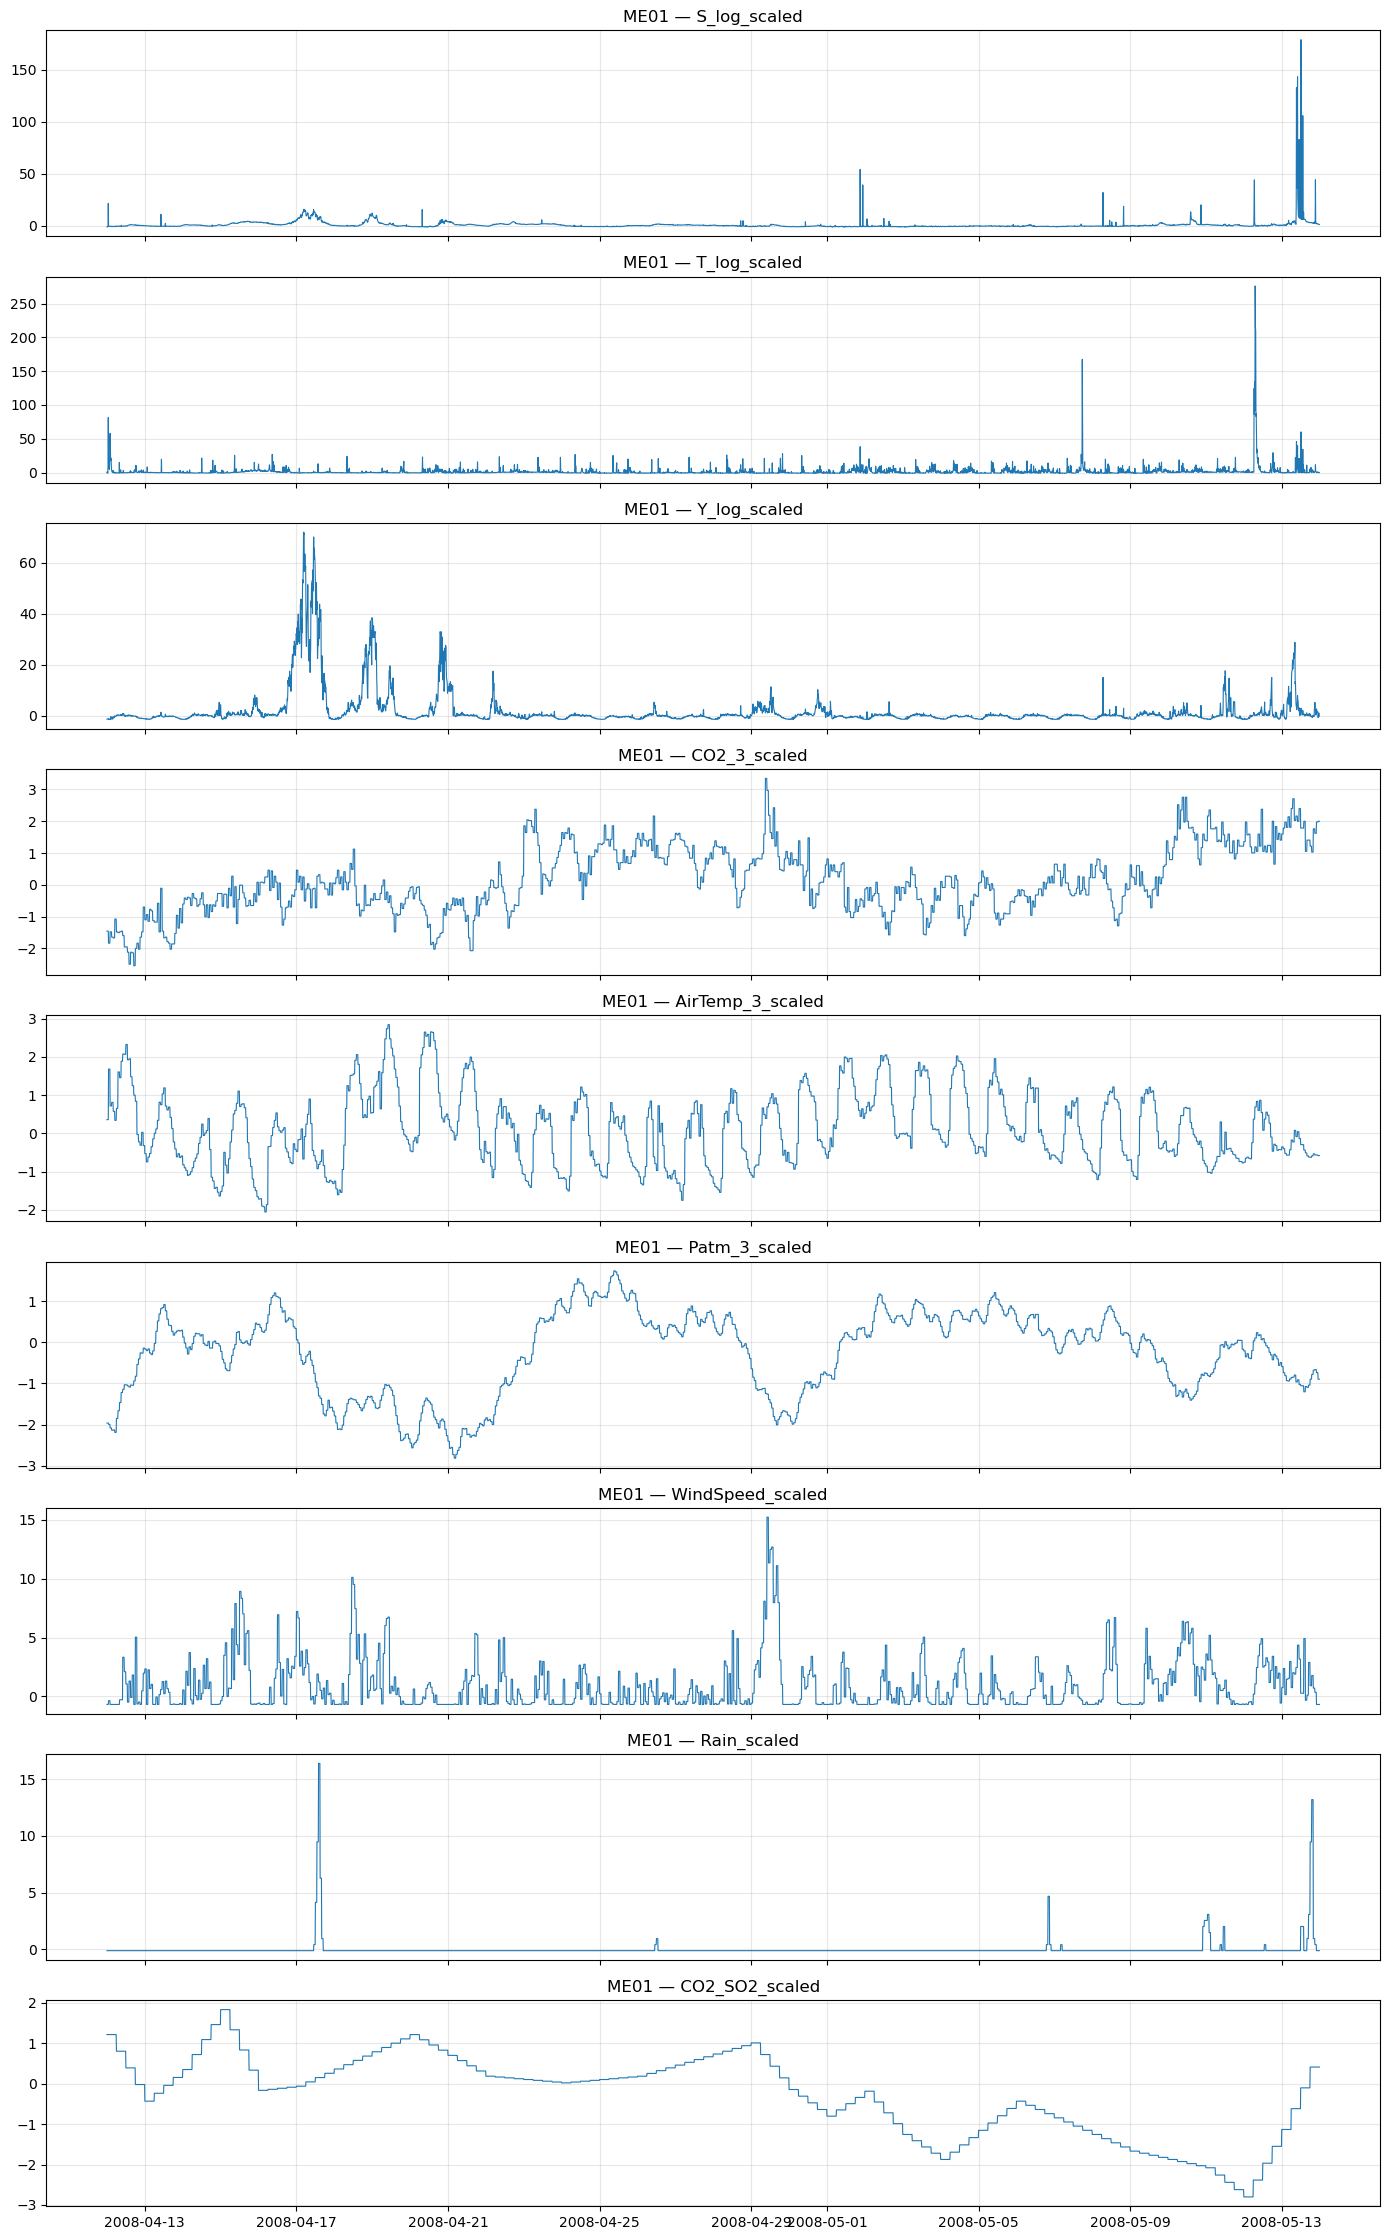

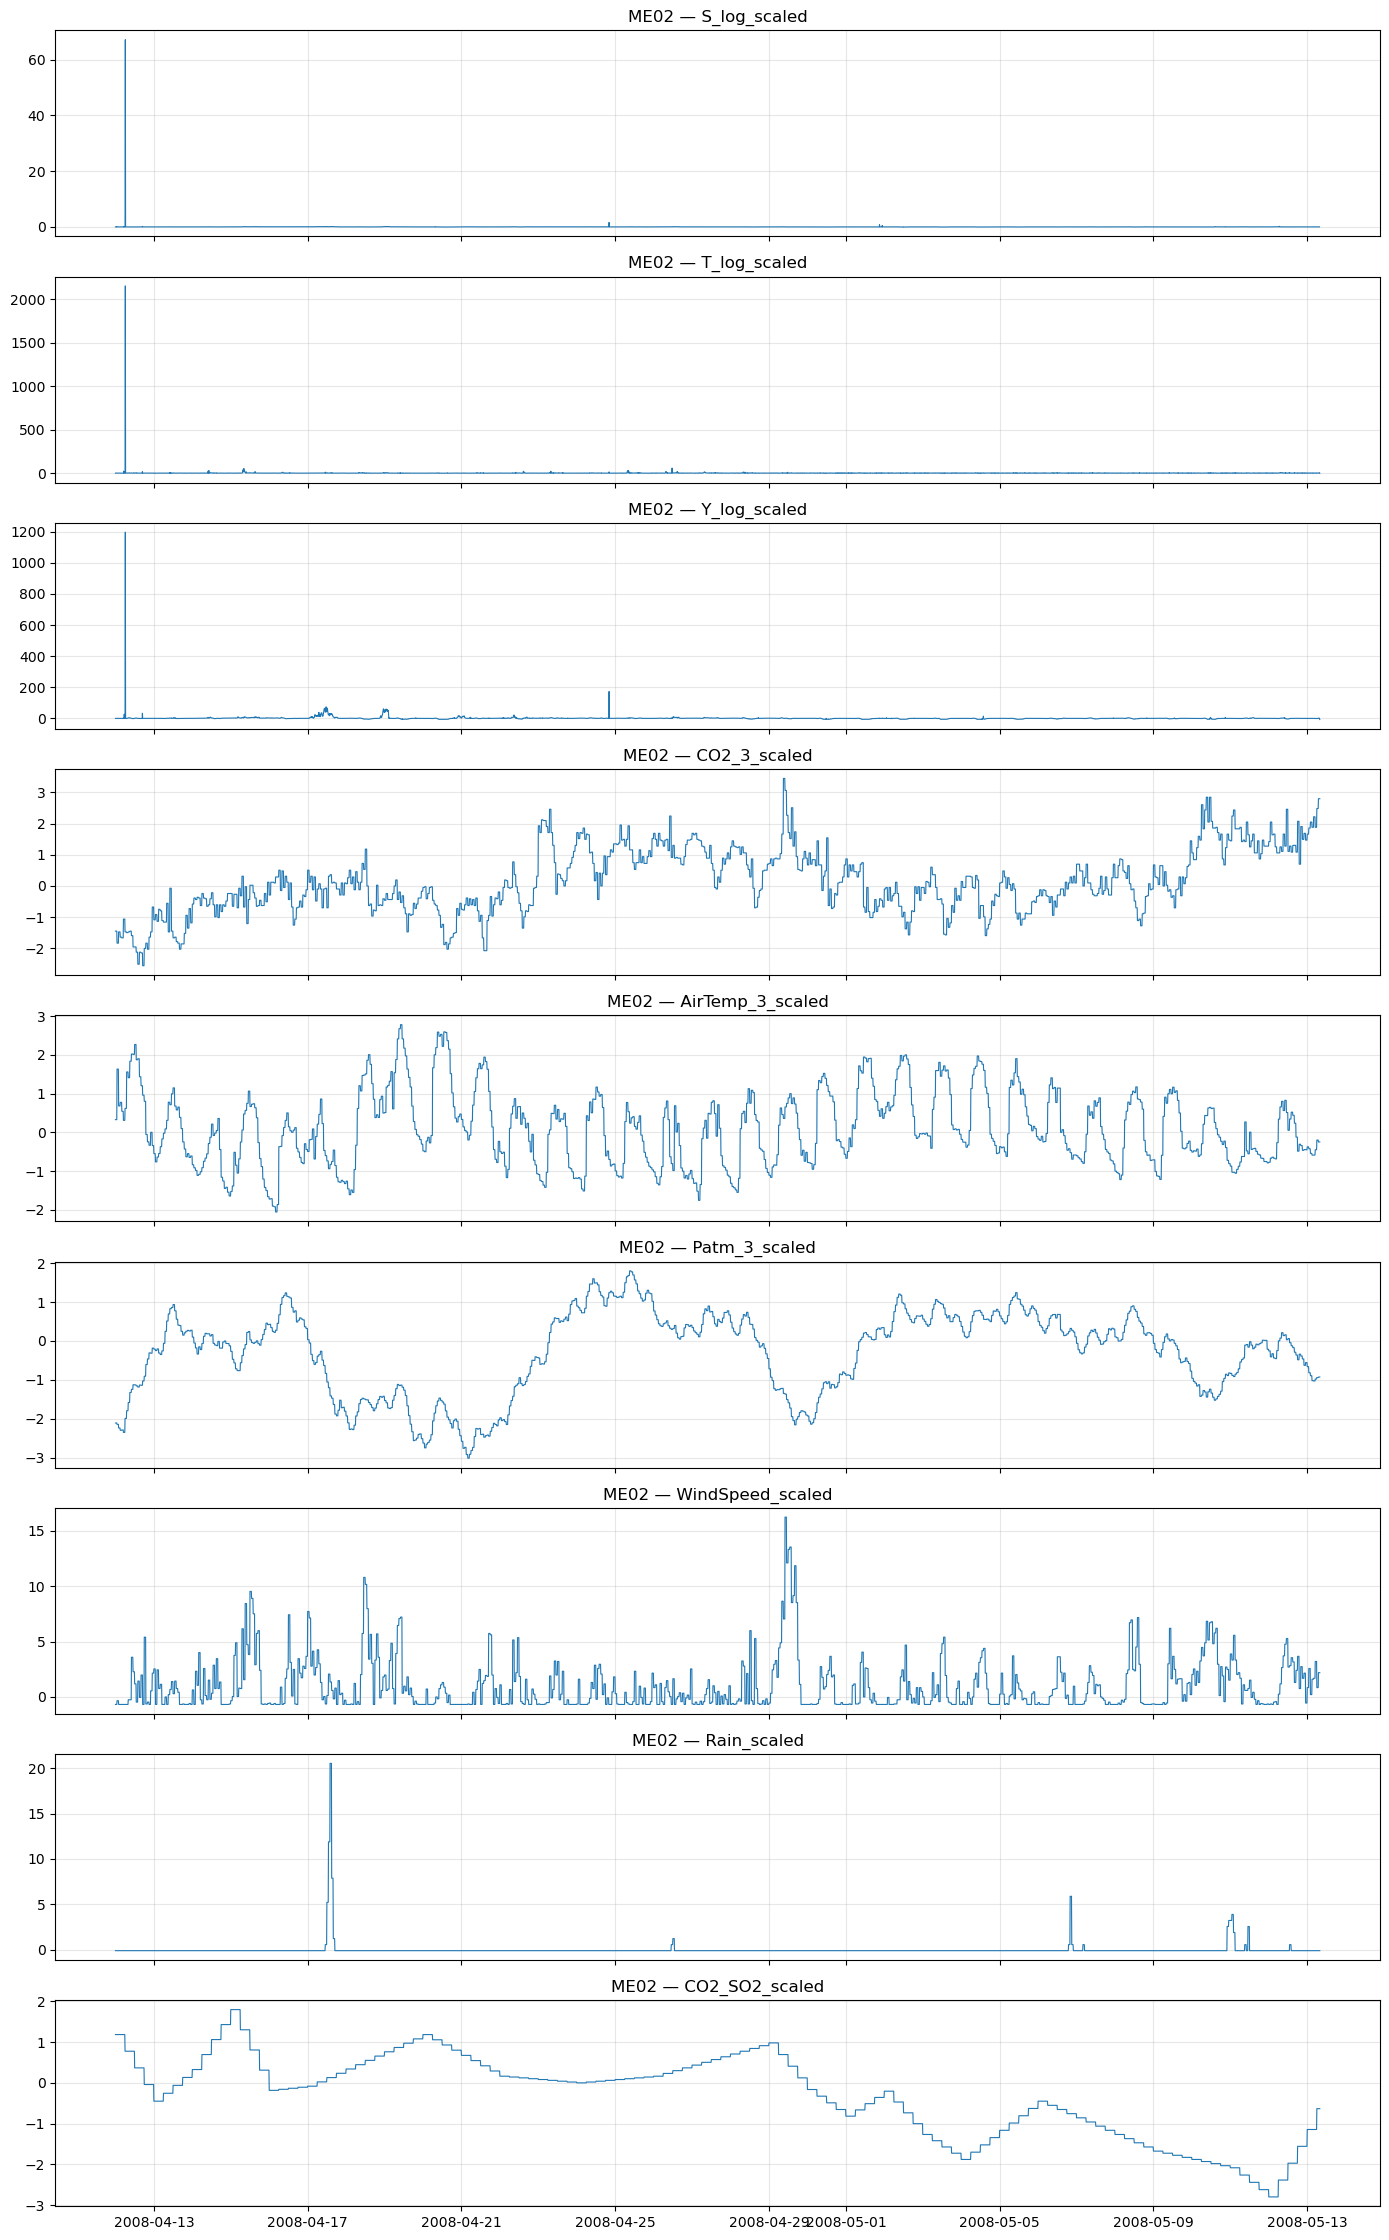

In [27]:
import matplotlib.pyplot as plt

def plot_scaled_dataset(df, station_name):
    cols = [c for c in df.columns if c.endswith("_scaled")]

    fig, axes = plt.subplots(len(cols), 1, figsize=(14, 2.5 * len(cols)), sharex=True)
    if len(cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, cols):
        ax.plot(df["time"], df[col], linewidth=0.8)
        ax.set_title(f"{station_name} — {col}")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

for sta, d in station_data.items():
    plot_scaled_dataset(d["final_scaled"], sta)


#### Compare ME01 and ME02 directly in one figure

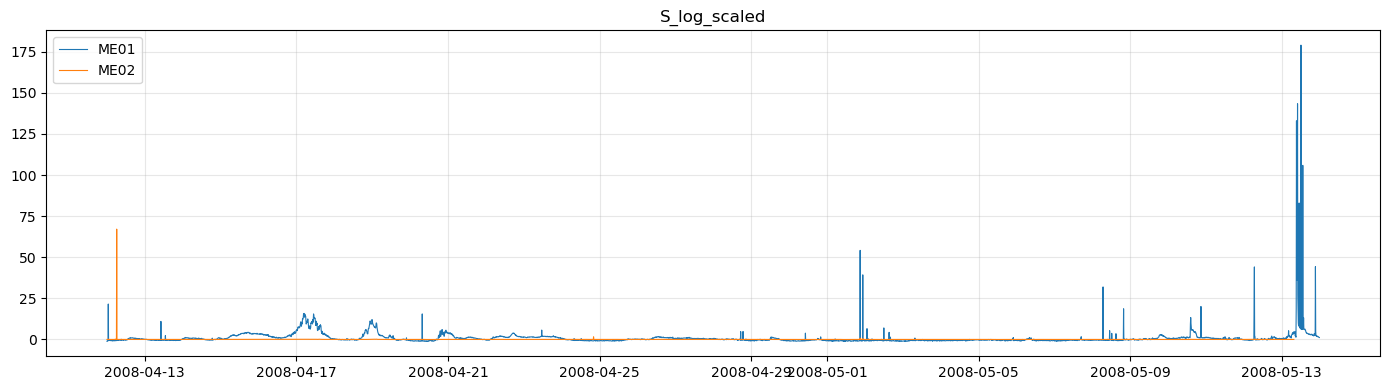

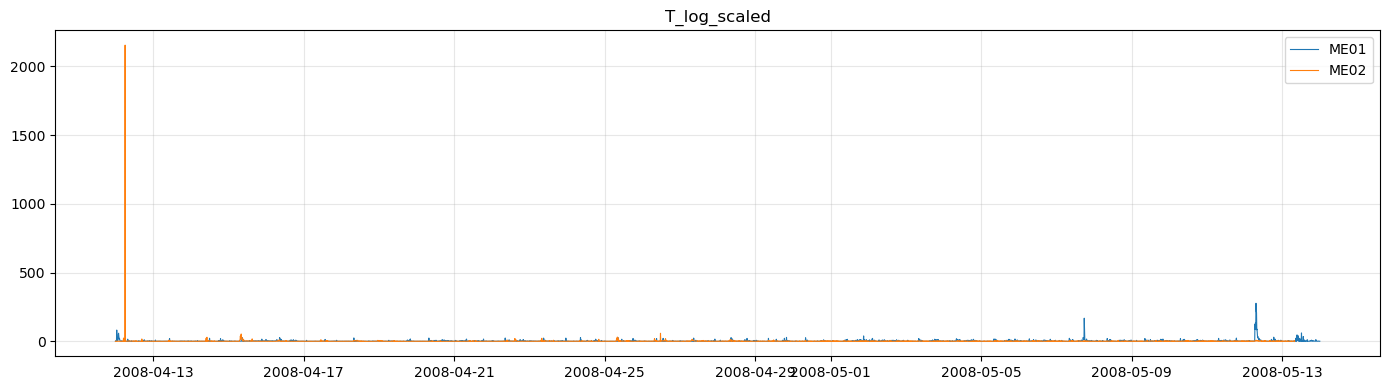

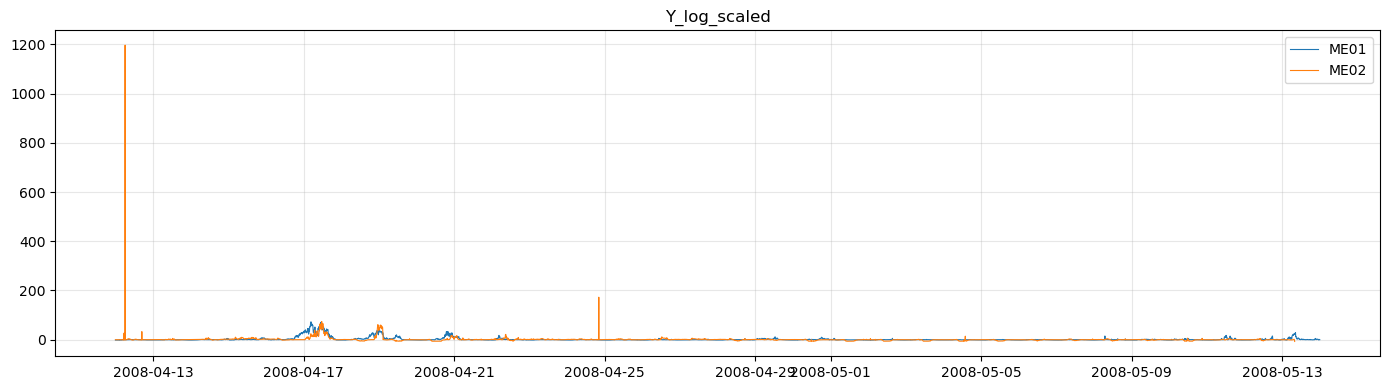

In [28]:
def compare_station_variable(df1, df2, var, name1="ME01", name2="ME02"):
    plt.figure(figsize=(14,4))
    plt.plot(df1["time"], df1[var], label=name1, linewidth=0.8)
    plt.plot(df2["time"], df2[var], label=name2, linewidth=0.8)
    plt.title(var)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

for var in ["S_log_scaled", "T_log_scaled", "Y_log_scaled"]:
    if var in final_me01_scaled.columns and var in final_me02_scaled.columns:
        compare_station_variable(final_me01_scaled, final_me02_scaled, var)


#### Inspecting teleseismic wave arrival considering Wenchuan earthquake event time and comparing 1-min time grid vs. 10-min vs grid

In [29]:
import matplotlib.dates as mdates

def run_teleseismic_checks(
    station,
    event_time=UTCDateTime("2008-05-12T06:28:00"),
    pre_sec=3600,
    post_sec=3600,
):
    t1 = event_time - pre_sec
    t2 = event_time + post_sec

    st = client.get_waveforms(
        network=CFG["network"],
        station=station,
        location=CFG["location"],
        channel=CFG["channel"],
        starttime=t1,
        endtime=t2,
        attach_response=True,
    )

    st.remove_response(output="VEL")
    tr = st[0]

    # -----------------------------
    # Raw waveform
    # -----------------------------
    plt.figure(figsize=(12, 4))
    plt.plot(tr.times("matplotlib"), tr.data)
    plt.title(f"Raw waveform around teleseismic arrival — {station}")
    plt.show()

    # -----------------------------
    # 1-min RMS
    # -----------------------------
    df = pd.DataFrame({
        "time": pd.to_datetime(tr.times("timestamp"), unit="s", utc=True),
        "amp": tr.data
    }).set_index("time")

    rms_1min = (
        df["amp"]
        .pow(2)
        .rolling("60s")
        .mean()
        .pow(0.5)
        .resample("1min")
        .mean()
    )

    # -----------------------------
    # 10-min RMS comparison
    # -----------------------------
    rms_10min = rms_1min.resample("10min").max()

    plt.figure(figsize=(12, 4))
    plt.plot(rms_1min.index, rms_1min, alpha=0.5, label="1-min RMS")
    plt.plot(rms_10min.index, rms_10min, marker="o", label="10-min RMS")
    plt.legend()
    plt.title(f"Effect of 10-minute aggregation — {station}")
    plt.show()

    t_peak_1m = rms_1min.idxmax()
    t_peak_10m = rms_10min.idxmax()

    print(f"\n{station}")
    print("1-min peak:", t_peak_1m)
    print("10-min peak:", t_peak_10m)
    print("difference:", t_peak_1m - t_peak_10m)

    # -----------------------------
    # Spectrogram
    # -----------------------------
    fig, ax = plt.subplots(figsize=(13, 6))

    tr_spec = tr.copy()

    Pxx, freqs, bins, _ = ax.specgram(
        tr_spec.data,
        NFFT=2048,
        Fs=tr_spec.stats.sampling_rate,
        noverlap=1536
    )

    ax.clear()

    start = tr_spec.stats.starttime.datetime
    bin_times = np.array([start + pd.Timedelta(seconds=b) for b in bins])
    bin_times = mdates.date2num(bin_times)

    ax.pcolormesh(
        bin_times,
        freqs,
        10 * np.log10(Pxx),
        shading="auto",
        cmap="viridis"
    )

    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    fig.autofmt_xdate()

    ax.axvline(
        mdates.date2num(event_time.datetime),
        color="white",
        linestyle="--",
        linewidth=2,
        label="EQ origin"
    )

    ax.axhline(0.2, color="white", linestyle=":", linewidth=2, label="T band upper")
    ax.axhline(4, color="orange", linestyle=":", linewidth=2, label="S band upper")
    ax.axhline(12, color="red", linestyle=":", linewidth=2, label="Y band upper")

    ax.set_ylim(0, 15)
    ax.set_ylabel("Frequency (Hz)")
    ax.set_xlabel("Time (UTC)")
    ax.set_title(f"Spectrogram around teleseismic arrival — Etna 2008-05-12 {station}")
    ax.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

    return {
        "station": station,
        "trace": tr,
        "rms_1min": rms_1min,
        "rms_10min": rms_10min,
        "t_peak_1m": t_peak_1m,
        "t_peak_10m": t_peak_10m,
        "peak_diff": t_peak_1m - t_peak_10m,
    }


c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\obspy\core\inventory\response.py:988: UserWarning: Input sampling rate of stage 3 is inconsistent with the previous stages' output sampling rate
  warnings.warn(msg % i)


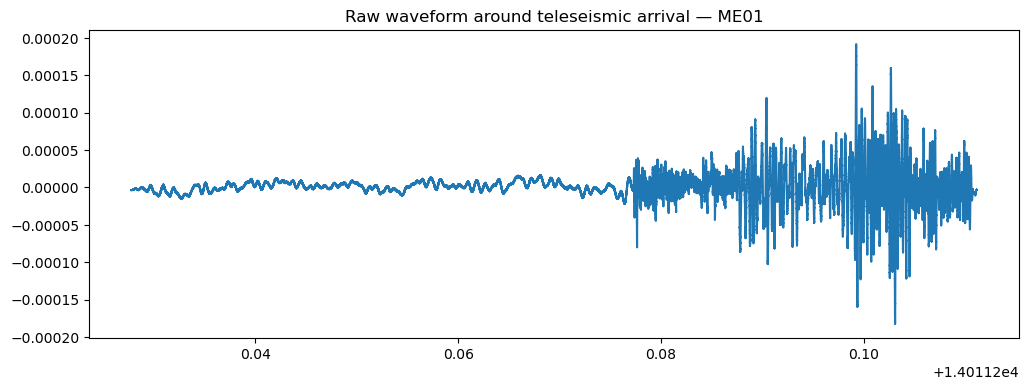

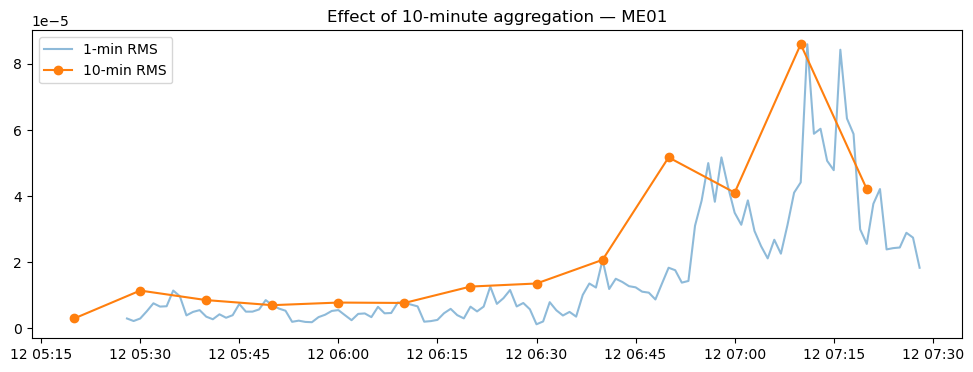


ME01
1-min peak: 2008-05-12 07:11:00+00:00
10-min peak: 2008-05-12 07:10:00+00:00
difference: 0 days 00:01:00


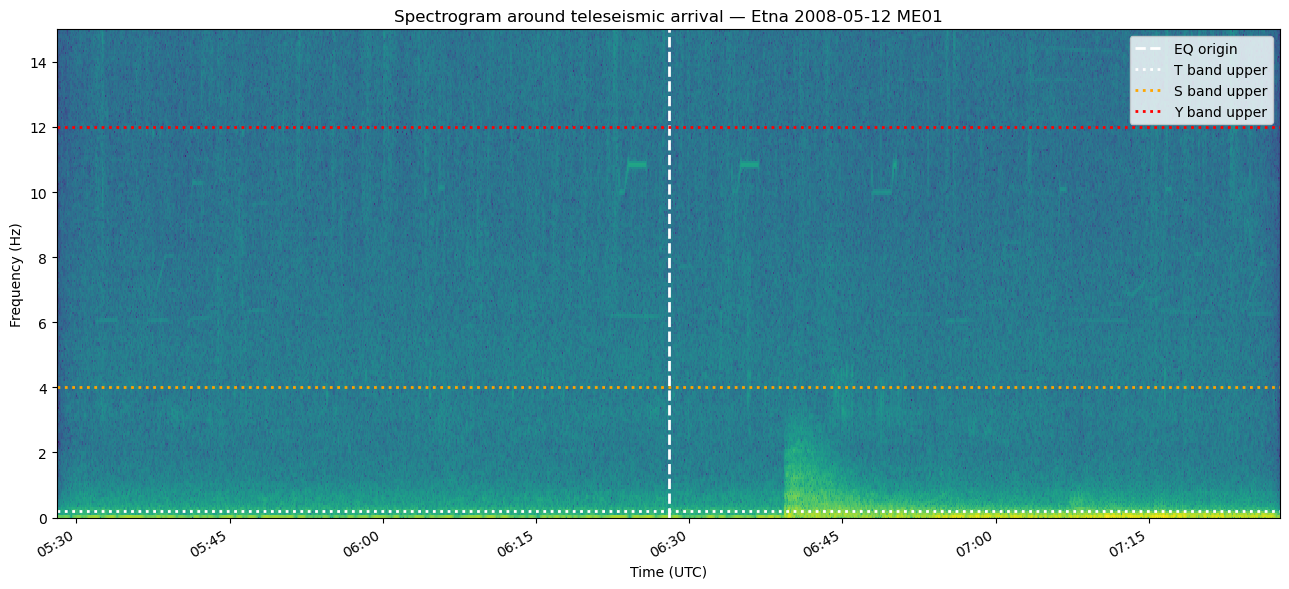

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\obspy\core\inventory\response.py:988: UserWarning: Input sampling rate of stage 3 is inconsistent with the previous stages' output sampling rate
  warnings.warn(msg % i)


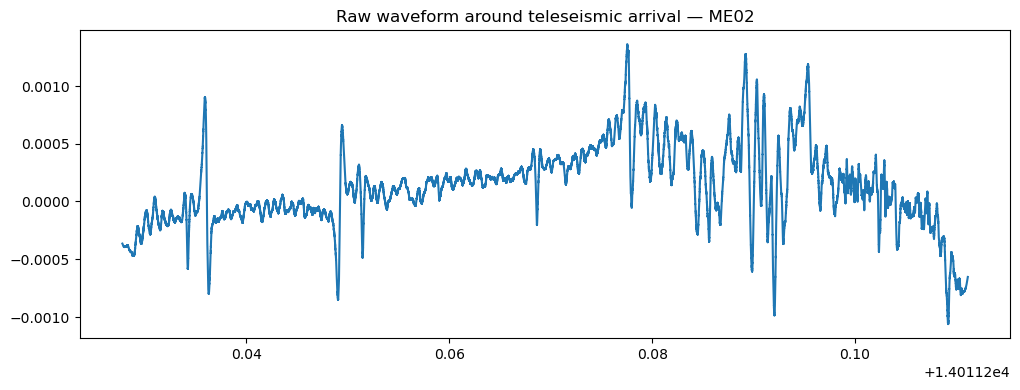

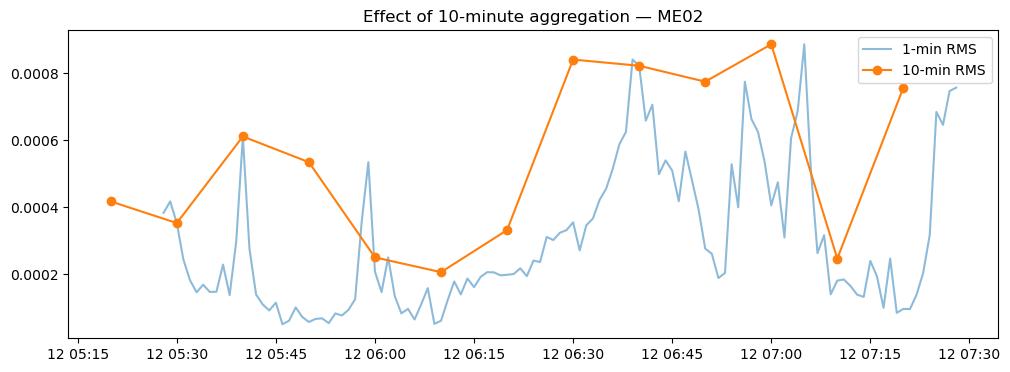


ME02
1-min peak: 2008-05-12 07:05:00+00:00
10-min peak: 2008-05-12 07:00:00+00:00
difference: 0 days 00:05:00


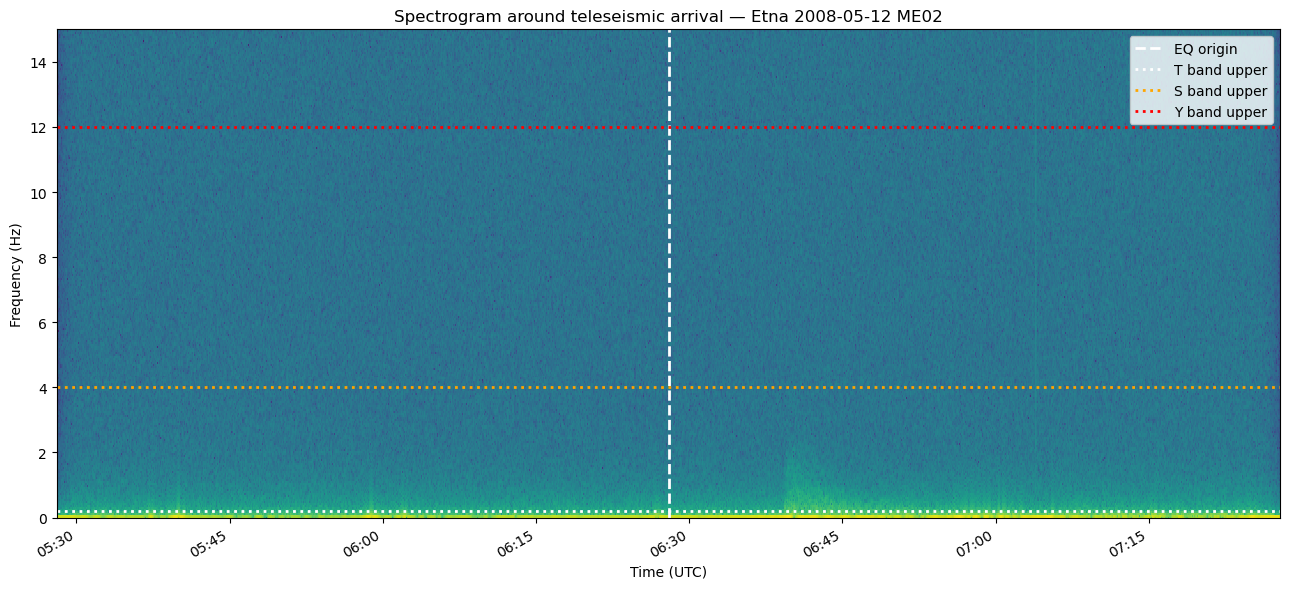

In [30]:
results = {}
for station in ["ME01", "ME02"]:
    results[station] = run_teleseismic_checks(station)


spectrogram is computed from the original high-resolution waveform

To evaluate the effect of temporal aggregation on teleseismic arrivals, waveform RMS energy was computed at 1-minute resolution and compared with the 10-minute aggregated feature series used in the final dataset. The peak arrival time differed by only ~1 minute, indicating that the 10-minute resolution preserves the timing and amplitude structure of the teleseismic energy burst.

The bright energy region appears after the earthquake origin line (~06:30) and is concentrated at very low frequencies (< ~1 Hz).

This is the classic signature of teleseismic surface waves.

ME01 showed the clearest teleseismic low-frequency arrival, while ME02 recorded the same event more weakly. Both stations were therefore retained as separate datasets and analyzed independently rather than merged, allowing station-specific sensitivity to the teleseismic disturbance to be assessed.

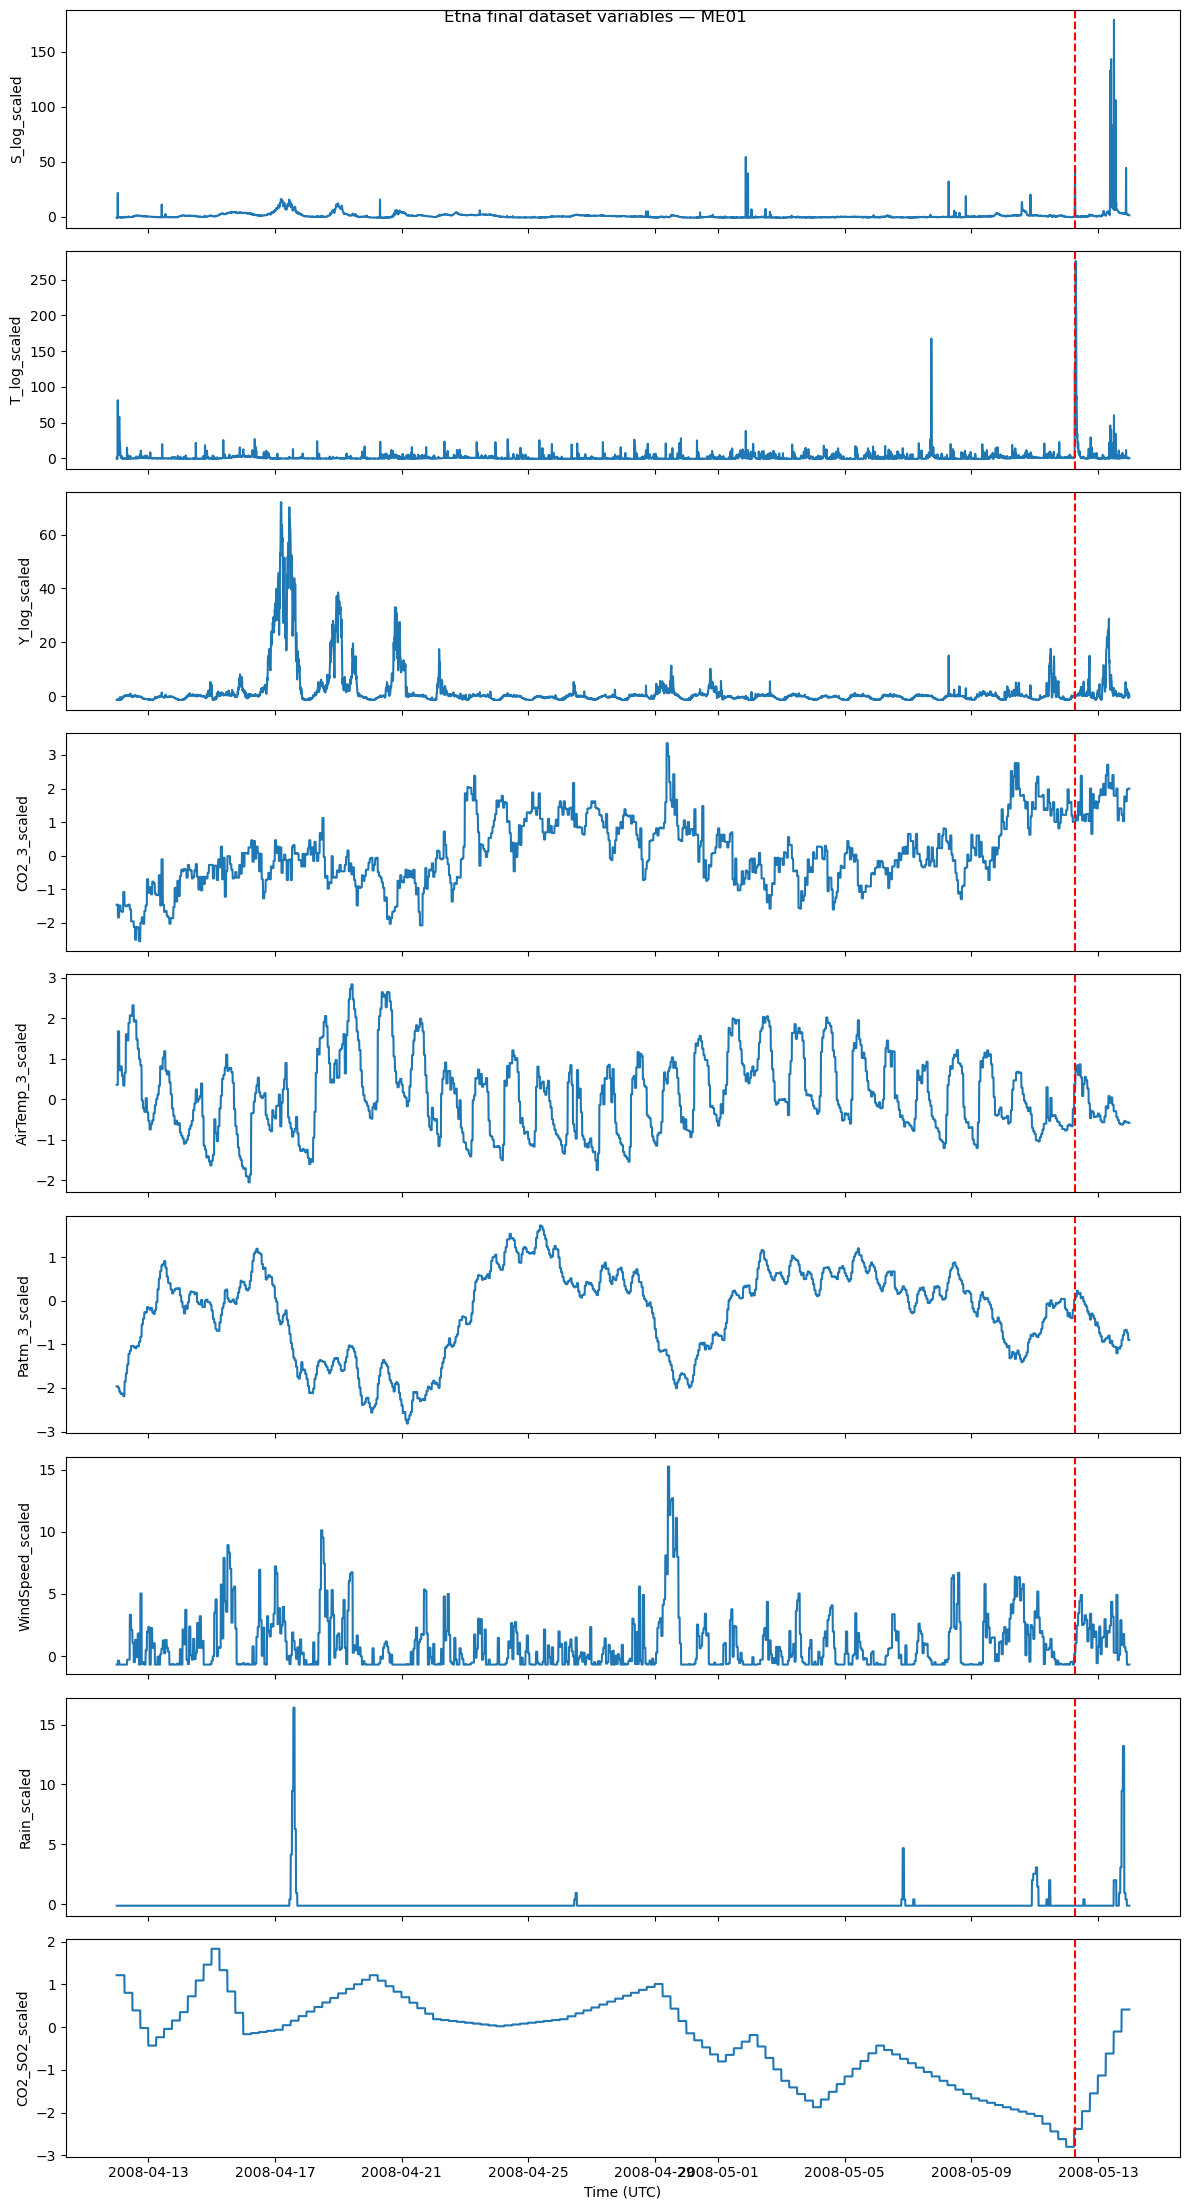

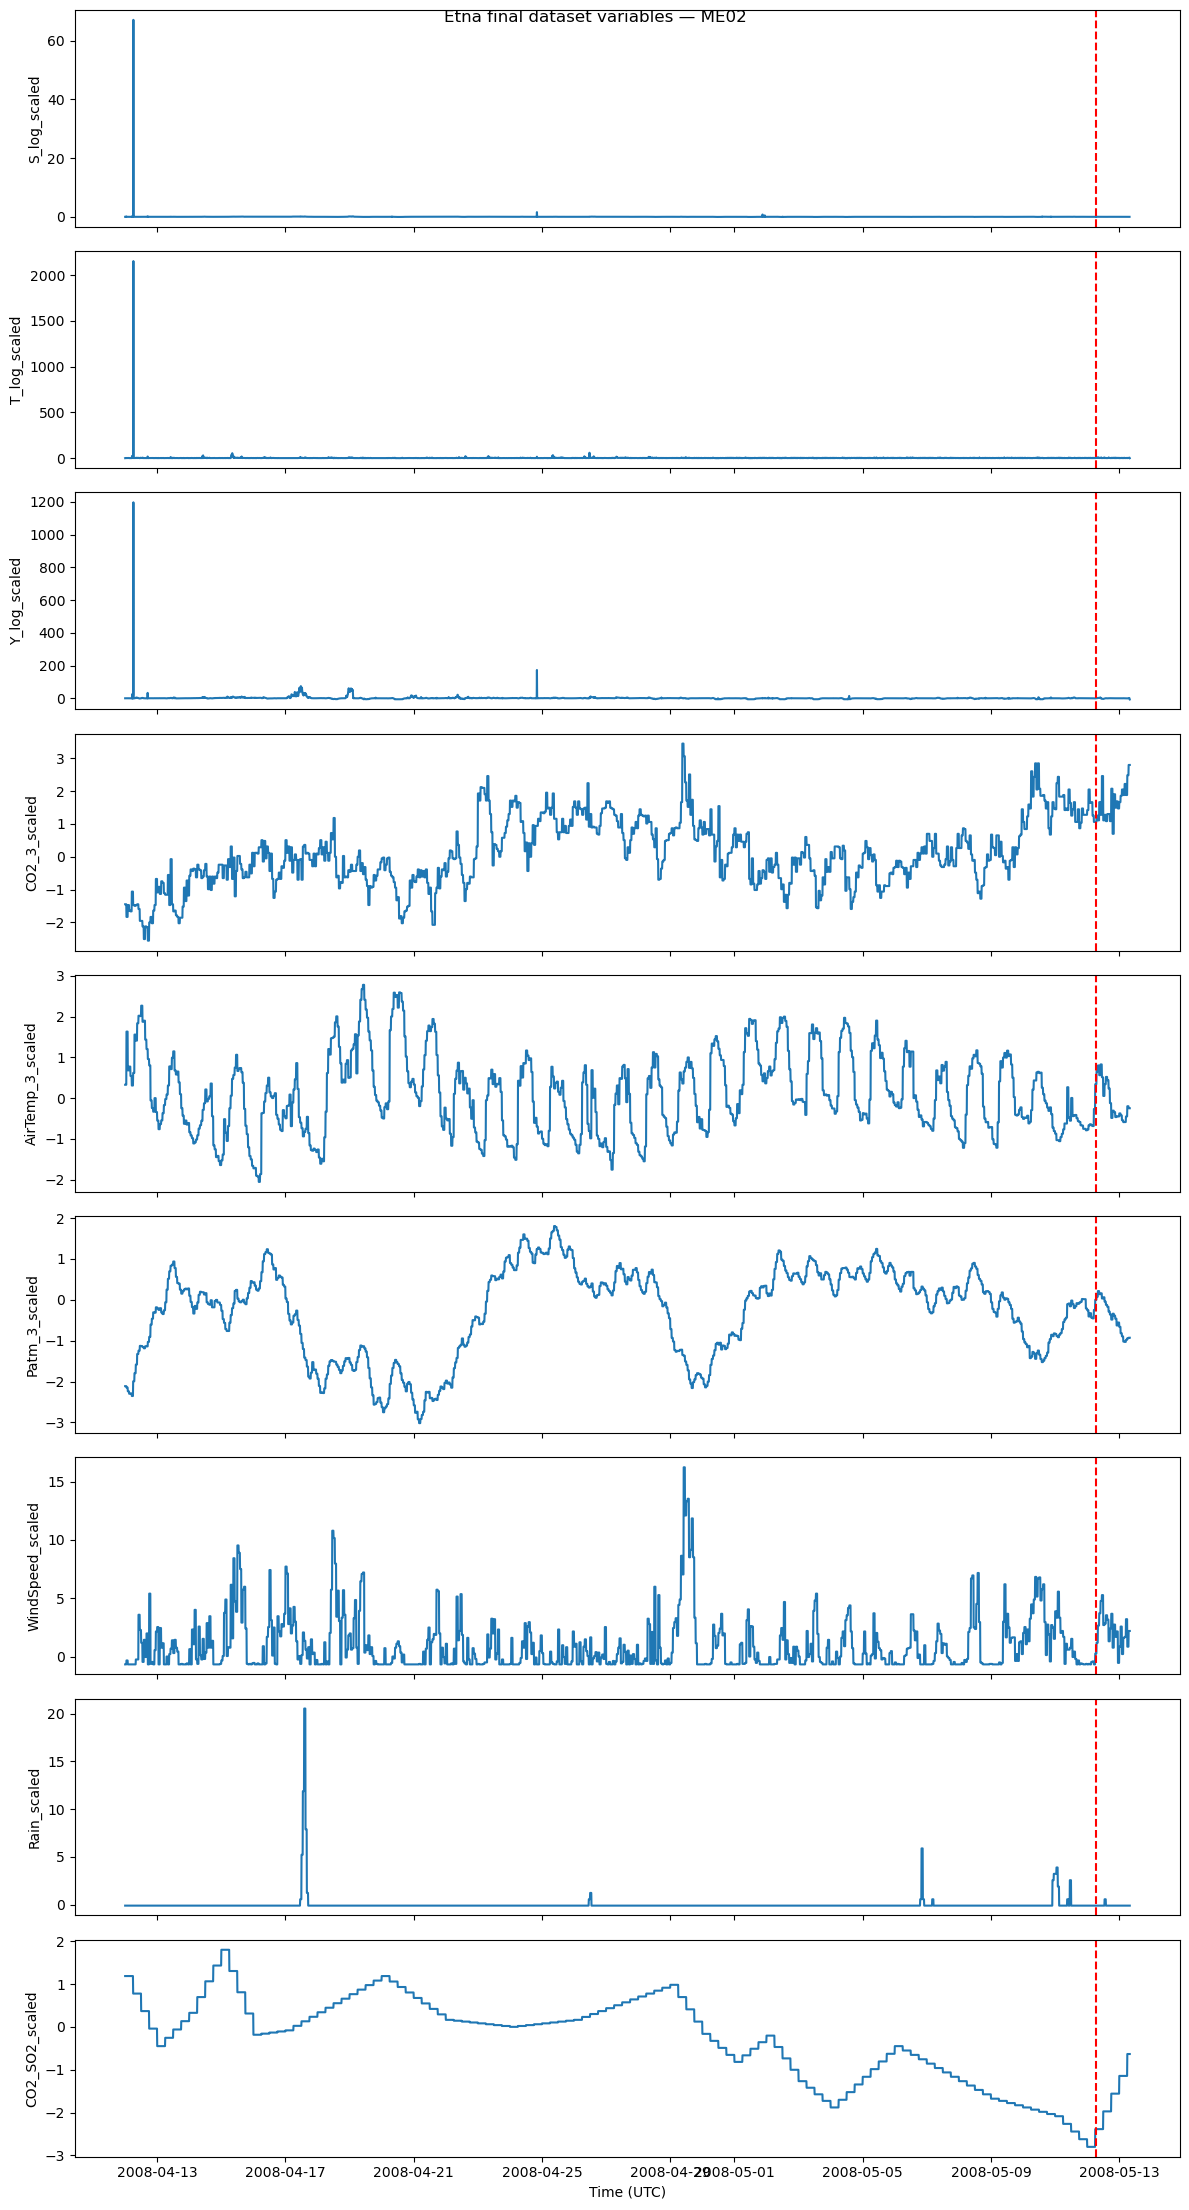

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

event_time = pd.Timestamp("2008-05-12T06:28:00", tz="UTC")

stations = ["ME01", "ME02"]

for station in stations:

    df = pd.read_csv(f"../etna_data/FINAL_{station}_scaled.csv", parse_dates=["time"])
    df = df.set_index("time")

    if "station" in df.columns:
        df = df.drop(columns=["station"])

    variables = df.columns

    fig, axes = plt.subplots(
        len(variables), 
        1, 
        figsize=(12, 2.5 * len(variables)), 
        sharex=True
    )

    for i, var in enumerate(variables):

        axes[i].plot(df.index, df[var])
        axes[i].axvline(event_time, color="red", linestyle="--")
        

        axes[i].set_ylabel(var)

    axes[-1].set_xlabel("Time (UTC)")
    fig.suptitle(f"Etna final dataset variables — {station}")

    plt.tight_layout()
    plt.show()